### Bayes Risk and Bayes Estimator for Normal R.V.

Given 1. **Likelihood**: Random variable $X \sim N(\theta, \sigma^2)$, where $\sigma^2$ is known and $\theta$ is unknown, & 2. **Prior**: The unknown mean $\theta$ is assumed to follow a $N(a, b^2)$, where $a$ is the prior mean and $b^2$ is the prior variance.
-   Derive the posterior distribution for $\theta$.
-   Determine the Bayes estimator for $\theta$ under a squared error loss function.
-   Calculate the Bayes risk associated with this estimator.

#### Posterior Distribution

For a Normal likelihood $X \sim N(\theta, \sigma^2)$ and a Normal prior $\theta \sim N(a, b^2)$, the posterior distribution for $\theta$ is also Normal $\theta|x \sim N(\hat{\theta}, \tau^2)$.
- Posterior Mean ($\hat{\theta}$): $\hat{\theta} = \frac{\frac{1}{\sigma^2}x + \frac{1}{b^2}a}{\frac{1}{\sigma^2} + \frac{1}{b^2}}$
- Posterior Variance ($\tau^2$): $\frac{1}{\tau^2} = \frac{1}{\sigma^2} + \frac{1}{b^2}$ (i.e., the posterior precision is the sum of likelihood precision and prior precision).

These are derived by combining the exponents of the likelihood and prior and completing the square.

In [1]:
import numpy as np

# Assume some values for the parameters
# Likelihood parameters
sigma_squared = 4.0 # Known variance
sigma = np.sqrt(sigma_squared)
x = 10.0 # Observed value of X

# Prior parameters
a = 8.0 # Prior mean
b_squared = 1.0 # Prior variance
b = np.sqrt(b_squared)

# Calculate posterior precision
posterior_precision = (1 / sigma_squared) + (1 / b_squared)
posterior_variance = 1 / posterior_precision
posterior_std_dev = np.sqrt(posterior_variance)

# Calculate posterior mean
posterior_mean = ((1 / sigma_squared) * x + (1 / b_squared) * a) / posterior_precision

#### Bayes Estimator and Bayes Risk

**Loss Function**: For estimation problems, a common choice is the **squared error loss** function, defined as $L(\theta, \hat{\theta}) = (\theta - \hat{\theta})^2$, where $\hat{\theta}$ is our estimator for $\theta$.

**Bayes Estimator**: The Bayes estimator $\hat{\theta}_{Bayes}$ is the estimator that minimizes the Bayes risk. For the squared error loss function, the Bayes estimator is simply the **posterior mean**.

In our case, the Bayes estimator for $\theta$ is $\hat{\theta}_{Bayes} = E[\theta|x] = \hat{\theta} = \frac{\frac{1}{\sigma^2}x + \frac{1}{b^2}a}{\frac{1}{\sigma^2} + \frac{1}{b^2}}$

**Bayes Risk**: The Bayes risk $R(\pi, \hat{\theta})$ is the expected value of the loss function averaged over the posterior distribution and then over the marginal distribution of $X$. More simply, for a given observation $x$, the **posterior risk** is the expected loss given $x$, $E[L(\theta, \hat{\theta})|x]$.

For squared error loss and the Bayes estimator (posterior mean), the posterior risk is the **posterior variance**
$E[(\theta - \hat{\theta}_{Bayes})^2|x] = E[(\theta - E[\theta|x])^2|x] = Var(\theta|x) = \tau^2$

So, the Bayes risk for our problem (under squared error loss) is the expected value of the posterior variance over all possible observations $x$. However, for a single observation $x$, the posterior risk is simply $\tau^2$.

#### Posterior and Bayes Estimator drawn from a Normal distribution. $\theta|X \sim N(\hat{\theta}, \tau^2)$

The mean of the Normal distribution is $\hat{\theta}$ and the mean of the posterior, and thus the Bayes estimator, is $\hat{\theta}(X)$.
For this specific case with one observation $X$, the Bayes estimator is $\hat{\theta}(X) = \frac{\frac{1}{\sigma^2}X + \frac{1}{b^2}a}{\frac{1}{\sigma^2} + \frac{1}{b^2}}$

If there were $N$ observations, and we used the sample mean $\bar{X}$, the formula would be:
$\hat{\theta}(\bar{X}) = \frac{\frac{N}{\sigma^2}\bar{X} + \frac{1}{b^2}a}{\frac{N}{\sigma^2} + \frac{1}{b^2}}$

Alternatively, this can be written as:
$\hat{\theta}(\bar{X}) = \frac{\sigma^2}{\sigma^2 + Nb^2}a + \frac{Nb^2}{\sigma^2 + Nb^2}\bar{X}$

In [2]:
import matplotlib.pyplot as plt

# Define a range of N values
n_values = np.arange(1, 101, 1) # N from 1 to 100

# Fix X_bar to the previously used observed value 'x'
X_bar_fixed = x # Our observed x (10.0) acts as the sample mean for N=1, but we'll fix it for larger N

# Calculate the posterior mean for each N
posterior_mean_vs_n = []
for n_val in n_values:
    posterior_mean_n = ((n_val / sigma_squared) * X_bar_fixed + (1 / b_squared) * a) / \
                       ((n_val / sigma_squared) + (1 / b_squared))
    posterior_mean_vs_n.append(posterior_mean_n)

In [3]:
import matplotlib.pyplot as plt

# Calculate posterior variance for each N
posterior_variance_vs_n = []
for n_val in n_values:
    posterior_precision_n = (n_val / sigma_squared) + (1 / b_squared)
    posterior_variance_n = 1 / posterior_precision_n
    posterior_variance_vs_n.append(posterior_variance_n)

### Bayes Risk and Bayes Estimator for Binomial R.V. with Beta Prior

Given 1. **Likelihood**: Random variable $X \sim Binomial(n, p)$, where $n$ is known and $p$ is unknown, & 2. **Prior**: The unknown probability $p$ is assumed to follow a $Beta(\alpha, \beta)$ distribution.

#### Posterior Distribution for Binomial-Beta

For a Binomial likelihood $X \sim Binomial(n, p)$ and a Beta prior $p \sim Beta(\alpha, \beta)$, the posterior distribution for $p$ is also a Beta distribution $p|x \sim Beta(\alpha', \beta')$.

The derivation is as follows:

*   **Likelihood**: $f(x|p) = \binom{n}{x} p^x (1-p)^{n-x}$
*   **Prior**: $f(p) = \frac{p^{\alpha-1}(1-p)^{\beta-1}}{B(\alpha, \beta)}$ (where $B(\alpha, \beta)$ is the Beta function)

According to Bayes' Theorem, the posterior is proportional to the likelihood times the prior:

$f(p|x) \propto f(x|p)f(p)$
$f(p|x) \propto \left[ \binom{n}{x} p^x (1-p)^{n-x} \right] \left[ \frac{p^{\alpha-1}(1-p)^{\beta-1}}{B(\alpha, \beta)} \right]$

Collecting terms involving $p$ and $(1-p)$:

$f(p|x) \propto p^{x+\alpha-1} (1-p)^{n-x+\beta-1}$

This expression is the kernel of a Beta distribution. Therefore, the posterior distribution is:

$p|x \sim Beta(\alpha', \beta')$ where:
-   Posterior Shape Parameter ($\alpha'$): $\alpha' = \alpha + x$
-   Posterior Shape Parameter ($\beta'$): $\beta' = \beta + n - x$

In [4]:
import numpy as np
from scipy.stats import beta

# Define parameters for Binomial Likelihood and Beta Prior

# Binomial Likelihood parameters
n = 10    # Number of trials
x = 7     # Observed number of successes

# Beta Prior parameters
alpha = 2 # Prior shape parameter (alpha)
beta_prior = 3 # Prior shape parameter (beta)

# Calculate Posterior Distribution Parameters
posterior_alpha = alpha + x
posterior_beta = beta_prior + n - x

# Calculate Bayes Estimator (Posterior Mean)
bayes_estimator = posterior_alpha / (posterior_alpha + posterior_beta)

# Calculate Bayes Risk (Posterior Variance)
posterior_variance = (posterior_alpha * posterior_beta) / \
                     ((posterior_alpha + posterior_beta)**2 * (posterior_alpha + posterior_beta + 1))

#### Bayes Estimator as a Function of Successes (x)

In [5]:
import matplotlib.pyplot as plt
from scipy.stats import beta

# Define a range of possible successes 'x' (from 0 to n)
x_values = np.arange(0, n + 1)

# Calculate Bayes estimator for each x
bayes_estimators_for_x = []
for current_x in x_values:
    posterior_alpha_for_x = alpha + current_x
    posterior_beta_for_x = beta_prior + n - current_x
    estimator = posterior_alpha_for_x / (posterior_alpha_for_x + posterior_beta_for_x)
    bayes_estimators_for_x.append(estimator)

# Calculate prior mean and MLE for reference
prior_mean = alpha / (alpha + beta_prior)
mle_values = x_values / n # Maximum Likelihood Estimator for p is x/n

#### Posterior Distribution for Varying Prior Parameters

In [6]:
import matplotlib.pyplot as plt
from scipy.stats import beta

# Define different sets of prior parameters to compare
prior_configs = [
    {'alpha': 1, 'beta': 1, 'label': 'Weak Prior (Uniform, Beta(1,1))'},
    {'alpha': 2, 'beta': 3, 'label': 'Original Prior (Beta(2,3))'},
    {'alpha': 5, 'beta': 1, 'label': 'Prior for High p (Beta(5,1))'},
    {'alpha': 10, 'beta': 10, 'label': 'Stronger Prior (Beta(10,10))'}
]

# Observed data (from previous setup)
n_obs = 10 ; x_obs = 7

# Range for p (probability) for plotting Beta PDF
p_range = np.linspace(0.001, 0.999, 500)

plt.figure(figsize=(13, 7), dpi=60)

for config in prior_configs:
    current_alpha = config['alpha']
    current_beta = config['beta']
    current_label = config['label']

    # Calculate posterior parameters for the current prior config
    posterior_alpha_var = current_alpha + x_obs
    posterior_beta_var = current_beta + n_obs - x_obs

<Figure size 780x420 with 0 Axes>

### Bayes Risk and Bayes Estimator for Poisson R.V. with Gamma Prior

Given 1. **Likelihood**: Random variable $X \sim Poisson(\lambda)$, where $\lambda$ is unknown, & 2. **Prior**: The unknown rate $\lambda$ is assumed to follow a $Gamma(\alpha, \beta)$ distribution.

#### Posterior Distribution for Poisson-Gamma

For a Poisson likelihood $X \sim Poisson(\lambda)$ and a Gamma prior $\lambda \sim Gamma(\alpha, \beta)$, the posterior distribution for $\lambda$ is also a Gamma distribution $\lambda|x \sim Gamma(\alpha', \beta')$.

The derivation follows:

*   **Likelihood**: $f(x|\lambda) = \frac{\lambda^x e^{-\lambda}}{x!}$
*   **Prior**: $f(\lambda) = \frac{\beta^\alpha}{\Gamma(\alpha)} \lambda^{\alpha-1} e^{-\beta\lambda}$ (for $\lambda > 0$)

According to Bayes' Theorem, the posterior is proportional to the likelihood times the prior
- $f(\lambda|x) \propto f(x|\lambda)f(\lambda)$, $f(\lambda|x) \propto \left[ \frac{\lambda^x e^{-\lambda}}{x!} \right] \left[ \frac{\beta^\alpha}{\Gamma(\alpha)} \lambda^{\alpha-1} e^{-\beta\lambda} \right]$

Collecting terms involving $\lambda$ and $e^{-\lambda}$
- $f(\lambda|x) \propto \lambda^{x+\alpha-1} e^{-(\lambda + \beta\lambda)}$, $f(\lambda|x) \propto \lambda^{x+\alpha-1} e^{-(\beta+1)\lambda}$

This expression is the kernel of a Gamma distribution. Therefore, the posterior distribution is $\lambda|x \sim Gamma(\alpha', \beta')$ where
-   Posterior Shape Parameter ($\alpha'$): $\alpha' = \alpha + x$
-   Posterior Rate Parameter ($\beta'$): $\beta' = \beta + 1$


In [7]:
import numpy as np
from scipy.stats import gamma

# Define parameters for Poisson Likelihood and Gamma Prior

# Poisson Likelihood parameters
x_observed = 5 # Observed number of events

# Gamma Prior parameters
alpha_prior = 2 # Prior shape parameter (alpha)
beta_prior = 1 # Prior rate parameter (beta)

# Calculate Posterior Distribution Parameters
posterior_alpha = alpha_prior + x_observed
posterior_beta = beta_prior + 1

# Calculate Bayes Estimator (Posterior Mean)
# For a Gamma distribution Gamma(alpha, beta), the mean is alpha / beta
bayes_estimator_poisson = posterior_alpha / posterior_beta

# Calculate Bayes Risk (Posterior Variance)
# For a Gamma distribution Gamma(alpha, beta), the variance is alpha / beta^2
posterior_variance_poisson = posterior_alpha / (posterior_beta**2)

#### Bayes Estimator and Bayes Risk for Poisson-Gamma

**Loss Function**: For estimation problems, a common choice is the **squared error loss** function, defined as $L(\lambda, \hat{\lambda}) = (\lambda - \hat{\lambda})^2$, where $\hat{\lambda}$ is our estimator for $\lambda$.

**Bayes Estimator**: The Bayes estimator $\hat{\lambda}_{Bayes}$ is the estimator that minimizes the Bayes risk. For the squared error loss function, the Bayes estimator is simply the **posterior mean**. In our case, the Bayes estimator for $\lambda$ is $\hat{\lambda}_{Bayes} = E[\lambda|x] = \frac{\alpha + x}{\beta + 1}$.

**Bayes Risk**: The Bayes risk $R(\pi, \hat{\lambda})$ is the expected value of the loss function averaged over the posterior distribution and then over the marginal distribution of $X$. For a given observation $x$, the **posterior risk** is the expected loss given $x$, $E[L(\lambda, \hat{\lambda})|x]$.

For squared error loss and the Bayes estimator (posterior mean), the posterior risk is the **posterior variance**. $E[(\lambda - \hat{\lambda}_{Bayes})^2|x] = E[(\lambda - E[\lambda|x])^2|x] = Var(\lambda|x) = \frac{\alpha + x}{(\beta + 1)^2}$.

So, the Bayes risk for our problem (under squared error loss), for a single observation $x$, is the posterior variance of the Gamma distribution.

#### Bayes Estimator as a Function of Observed Events (x) for Poisson-Gamma

In [8]:
import matplotlib.pyplot as plt

# Re-using prior parameters defined earlier
# alpha_prior = 2
# beta_prior = 1

# Define a range of possible observed events 'x'
x_values_poisson = np.arange(0, 21) # From 0 to 20 events

# Calculate Bayes estimator for each x
bayes_estimators_for_x_poisson = []
for current_x in x_values_poisson:
    posterior_alpha_for_x = alpha_prior + current_x
    posterior_beta_for_x = beta_prior + 1 # beta_prior remains constant
    estimator = posterior_alpha_for_x / posterior_beta_for_x
    bayes_estimators_for_x_poisson.append(estimator)

# Calculate prior mean and MLE for reference
prior_mean_poisson = alpha_prior / beta_prior # Mean of Gamma prior
mle_values_poisson = x_values_poisson # MLE for Poisson is simply x

#### Posterior Distribution for Varying Prior Parameters (Poisson-Gamma)

In [9]:
import matplotlib.pyplot as plt
from scipy.stats import gamma

# Define different sets of prior parameters to compare
prior_configs_poisson = [
    {'alpha': 1, 'beta': 1, 'label': 'Weak Prior (Gamma(1,1))'},
    {'alpha': 2, 'beta': 1, 'label': 'Original Prior (Gamma(2,1))'},
    {'alpha': 5, 'beta': 0.5, 'label': 'Prior for High lambda (Gamma(5,0.5))'},
    {'alpha': 10, 'beta': 5, 'label': 'Stronger Prior (Gamma(10,5))'}
]

# Observed data (from previous setup)
x_obs_poisson = 5 # Observed number of events

# Range for lambda (rate) for plotting Gamma PDF
lambda_range = np.linspace(0.01, 15, 500) # Adjust range as needed for different priors

for config in prior_configs_poisson:
    current_alpha_p = config['alpha']
    current_beta_p = config['beta']
    current_label_p = config['label']

    # Calculate posterior parameters for the current prior config
    posterior_alpha_var_p = current_alpha_p + x_obs_poisson
    posterior_beta_var_p = current_beta_p + 1

### Bayes Estimator under Zero-One Loss

Given a finite parameter space $\Theta = \{\theta_1, \dots, \theta_k\}$ and a zero-one loss function, the Bayes estimator is the posterior mode.

**Zero-One Loss Function:**
The zero-one loss function is defined as:
$L(\theta, \hat{\theta}) = \begin{cases} 0 & \text{if } \hat{\theta} = \theta \\ 1 & \text{if } \hat{\theta} \neq \theta \end{cases}$

**Bayes Risk:**
The Bayes estimator $\hat{\theta}_{Bayes}(x)$ minimizes the posterior risk (expected loss) for a given observation $x$:
$E[L(\theta, \hat{\theta}(x))|x] = \sum_{\theta \in \Theta} L(\theta, \hat{\theta}(x)) P(\theta|x)$

Substituting the zero-one loss function: $E[L(\theta, \hat{\theta}(x))|x] = \sum_{\theta \neq \hat{\theta}(x)} 1 \cdot P(\theta|x) + \sum_{\theta = \hat{\theta}(x)} 0 \cdot P(\theta|x)$, $E[L(\theta, \hat{\theta}(x))|x] = \sum_{\theta \neq \hat{\theta}(x)} P(\theta|x)$

We know that $\sum_{\theta \in \Theta} P(\theta|x) = 1$. Therefore, we can rewrite the expression as:
$E[L(\theta, \hat{\theta}(x))|x] = 1 - P(\hat{\theta}(x)|x)$

**Minimizing the Posterior Risk:**
To minimize $E[L(\theta, \hat{\theta}(x))|x]$, we need to maximize $P(\hat{\theta}(x)|x)$.

This means that the Bayes estimator $\hat{\theta}_{Bayes}(x)$ should be the value of $\theta$ that has the highest posterior probability given $x$. In other words, the Bayes estimator under zero-one loss is the **posterior mode**.

$\hat{\theta}_{Bayes}(x) = \arg\max_{\theta \in \Theta} P(\theta|x)$

### Optimal Estimator for Variance under a Specific Loss Function

Given a sample $X_1, \dots, X_n$ from a distribution with variance $\sigma^2$, we consider estimators of the form $\hat{\sigma}^2 = bS^2$, where $S^2$ is the unbiased sample variance, $S^2 = \frac{1}{n-1}\sum_{i=1}^n (X_i - \bar{X})^2$.

The loss function for estimating $\sigma^2$ is given by
$L(\sigma^2, \hat{\sigma}^2) = \frac{\hat{\sigma}^2}{\sigma^2} - 1 - \log\left(\frac{\hat{\sigma}^2}{\sigma^2}\right)$

We want to find the optimal value of $b$ that minimizes the risk
- $R(\sigma^2, b) = E[L(\sigma^2, bS^2)]$, for all $\sigma^2$.

**1. Substitute the estimator into the loss function:**
Let $\hat{\sigma}^2 = bS^2$. The loss function becomes
- $L(\sigma^2, bS^2) = \frac{bS^2}{\sigma^2} - 1 - \log\left(\frac{bS^2}{\sigma^2}\right)$

**2. Calculate the Risk Function:**
The risk function is the expected value of the loss:
$R(\sigma^2, b) = E\left[\frac{bS^2}{\sigma^2} - 1 - \log\left(\frac{bS^2}{\sigma^2}\right)\right]$

Using linearity of expectation and properties of logarithms
- $R(\sigma^2, b) = b - 1 - \log(b) - E\left[\log\left(\frac{S^2}{\sigma^2}\right)\right]$

Let $Y = \frac{S^2}{\sigma^2}$, the risk function can be written as
- $R(\sigma^2, b) = b - 1 - \log(b) - E[\log(Y)]$

Notice that the term $E[\log(Y)]$ does not depend on $b$ or $\sigma^2$, it is a constant with respect to $b$.

**3. Minimize the Risk with respect to $b$:**
To find the optimal value of $b$, we take the derivative of the risk function with respect to $b$ and set it to zero:
$\frac{\partial R}{\partial b} = 1 - \frac{1}{b}$. Setting the derivative to zero $b = 1$.

To confirm this is a minimum, we check the second derivative $\frac{\partial^2 R}{\partial b^2} = \frac{\partial}{\partial b} (1 - \frac{1}{b}) = \frac{1}{b^2}$. Since $S^2 \ge 0$, $b$ must be positive, so $\frac{1}{b^2} > 0$. This confirms that $b=1$ is indeed a minimum.

**Conclusion:**
The optimal value of $b$ that minimizes the risk for all $\sigma^2$ is $\mathbf{b=1}$.
This means that under this specific loss function, the unbiased sample variance $S^2$ (i.e., when $b=1$) is the optimal estimator for $\sigma^2$.

### Admissibility and Minimaxity of $\bar{X}$

Let $X_1, \dots, X_n \sim N(\theta, \sigma^2)$, where $\theta$ is unknown and $\sigma^2$ is known. Consider the loss function $L(\theta, \hat{\theta}) = (\theta - \hat{\theta})^2/\sigma^2$. The sample mean $\bar{X}$ is both an admissible and minimax estimator for $\theta$.

#### Admissibility and Minimaxity of $\bar{X}$ for $X_1,...,X_n \sim N(\theta, \sigma^2)$ with Loss $L(\theta, \hat{\theta}) = (\theta - \hat{\theta})^2/\sigma^2$

For the scenario where we have observations $X_1, \dots, X_n \sim N(\theta, \sigma^2)$ and a loss function $L(\theta, \hat{\theta}) = (\theta - \hat{\theta})^2/\sigma^2$, the sample mean $\bar{X}$ is both an admissible and minimax estimator for $\theta$.

**1. Admissibility of $\bar{X}$:**

- For the Normal distribution, $\bar{X}$ is the Uniformly Minimum Variance Unbiased Estimator (UMVUE) for $\theta$. In many regular cases, UMVUEs are admissible.
- $\bar{X}$ can be shown to be a Bayes estimator for $\theta$ with respect to an improper uniform prior, $p(\theta) \propto 1$. For squared error loss (or scaled squared error loss as given), if an estimator is a unique Bayes estimator, it is often admissible. In this case, the posterior mean derived from an improper uniform prior is $\bar{X}$, and since the Normal distribution is a regular exponential family, this estimator is unique and thus admissible.

**2. Minimaxity of $\bar{X}$:**

*   **Constant Risk**: The risk function for $\bar{X}$ under the given loss function is $R(\theta, \bar{X}) = E[L(\theta, \bar{X})] = E[(\theta - \bar{X})^2/\sigma^2]$. We know that $Var(\bar{X}) = \sigma^2/n$. Thus, $E[(\theta - \bar{X})^2] = Var(\bar{X}) + (E[\bar{X}] - \theta)^2 = \sigma^2/n + (\theta - \theta)^2 = \sigma^2/n$. Therefore, the risk is $R(\theta, \bar{X}) = (\sigma^2/n) / \sigma^2 = 1/n$. This risk is constant for all $\theta$. An estimator with constant risk is a strong candidate for minimaxity.
*   **Bayes Estimator with respect to a Least Favorable Prior**: An estimator with constant risk that is also a Bayes estimator with respect to a least favorable prior is a minimax estimator. For the Normal mean with squared error loss, the improper uniform prior $p(\theta) \propto 1$ is a least favorable prior. As established, $\bar{X}$ is the Bayes estimator for this prior.

Therefore, because $\bar{X}$ is a Bayes estimator with respect to a least favorable (improper uniform) prior and has a constant risk, it is a minimax estimator.

### Unique Minimax Rule under Specific Loss for Binomial Distribution

Given $X \sim Binomial(n, p)$ and the loss function $L(p, \hat{p}) = (1 - \hat{p}/p)^2$, where $0 < p < 1$. We want to show that the estimator $\hat{p}(X) = 0$ is the unique, minimax rule.

**1. Calculate the Risk Function for $\hat{p}(X) = 0$**

The risk for the estimator $\hat{p}(X) = 0$ is defined as $R(p, \hat{p}(X)=0) = E[L(p, 0) | p] = 1$. Since the risk $R(p, \hat{p}(X)=0) = 1$ for all $p \in (0, 1)$, $\sup_{p \in (0,1)} R(p, 0) = 1$.

**2. Prove Minimaxity and Uniqueness**

An estimator $\delta^*$ is minimax if its maximum risk is the smallest possible among all estimators. That is, $\sup_p R(p, \delta^*) = \inf_\delta \sup_p R(p, \delta)$. We need to show that no other estimator $\hat{p}'(X)$ can achieve a maximum risk less than 1, and that if an estimator achieves a maximum risk of 1, it must be $\hat{p}(X) = 0$.

For estimator $\hat{p}(X) = 0$, the loss function is always 1, so the risk is also 1.

For any estimator $\tilde{p}(X)$ that falls within the parameter space $(0, 1)$, we calculate its maximum risk $R_{bar}(p, \tilde{p}) = \sup_p R(p, \tilde{p})$.

$R(p, \tilde{p}) = E_p[(1 - \tilde{p}(X)/p)^2] = 1 + \frac{1}{p}(-2E_p [\tilde{p}(X)]) + \frac{1}{p^2} E_p[\tilde{p}(X)^2]$

For a specific estimator, we have the expectations as constants, $a = E_p[\tilde{p}(X)]$ and $b = E_p[\tilde{p}(X)^2]$. We are interested in picking a $p \in (0, 1)$ such that this risk is greater than 1; we can always do $p = a/b < 2a/b$, since $a > 0$ due to the open interval constraint.

$1 + \frac{1}{p}(-2a) + \frac{1}{p^2}b > 1$
$\frac{1}{p}(-2a + \frac{1}{p}b) > 0$
$p < 2a/b$

Therefore, any estimator within the parameter space can produce a risk greater than 1, and it is not minimax as the estimator $\hat{p}(X) = 0$ produces a smaller maximum risk.

### Inadmissibility of $\bar{X}$ for Multiple Normal Means ($k \ge 3$) and the James-Stein Estimator

While for a single normal mean ($k=1$), the sample mean $\hat{\theta}(X) = X$ (or $\bar{X}$) is admissible under squared error loss, this is not always true when estimating multiple parameters simultaneously.

Consider the generalization to $k$ normal means. Let $\theta = (\theta_1, \dots, \theta_k)$ and $X = (X_1, \dots, X_k)$ with $X_i \sim N(\theta_i, 1)$ independently, and the loss function $L(\theta, \hat{\theta}) = \sum_{j=1}^k (\theta_j - \hat{\theta}_j)^2$.

**Stein's Paradox**: Stein proved that, if $k \ge 3$, then the natural estimator $\hat{\theta}(X) = X$ is **inadmissible**. This means there exists another estimator that has uniformly smaller risk than $X$.

One such estimator is the **James-Stein estimator**, which can be shown to have smaller risk:

$\hat{\theta}_S(X) = \left(1 - \frac{k - 2}{\sum_{i=1}^k X_i^2}\right)_+ \cdot X_i$

where $(z)_+ = \max\{z, 0\}$. This estimator shrinks the $X_i$'s towards 0. The profound message from this result is that, when estimating many parameters simultaneously, there can be significant value in "shrinking" the estimates towards a common point (like 0, in this case). This observation plays an important role in modern statistical methods, including non-parametric function estimation and regularization techniques.

#### Simulation: Comparing MLE and James-Stein Estimator Risks

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_data(theta_true, k, sigma_squared=1):
    """Generates k observations X_i ~ N(theta_i, sigma_squared)."""
    return np.random.normal(loc=theta_true, scale=np.sqrt(sigma_squared), size=k)

def mle_estimator(X):
    """The MLE for theta_i is X_i."""
    return X

def james_stein_estimator(X, k):
    """Calculates the James-Stein estimator.
    X: vector of observations (X_1, ..., X_k)
    k: number of dimensions/parameters
    """
    sum_sq_X = np.sum(X**2)
    # Avoid division by zero if sum_sq_X is extremely small
    if sum_sq_X == 0:
        return np.zeros(k)

    # Calculate the shrinkage factor
    shrinkage_factor = max(0, 1 - (k - 2) / sum_sq_X)
    return shrinkage_factor * X

def squared_error_loss(theta_true, theta_hat):
    """Calculates the sum of squared errors."""
    return np.sum((theta_true - theta_hat)**2)

Now, let's define a function to run the simulations and compute the empirical risk for both estimators.

In [11]:
def run_simulation(k, theta_true, num_simulations=10000):
    """Runs simulations to compare MLE and James-Stein risks.

    Args:
        k (int): Number of normal means/dimensions.
        theta_true (np.array): True vector of means (k-dimensional).
        num_simulations (int): Number of simulation runs.

    Returns:
        tuple: (average_mle_loss, average_js_loss)
    """
    mle_losses = []
    js_losses = []

    for _ in range(num_simulations):
        # Simulate data
        X = simulate_data(theta_true, k)

        # Calculate estimators
        theta_hat_mle = mle_estimator(X)
        theta_hat_js = james_stein_estimator(X, k)

        # Calculate loss
        mle_losses.append(squared_error_loss(theta_true, theta_hat_mle))
        js_losses.append(squared_error_loss(theta_true, theta_hat_js))

    return np.mean(mle_losses), np.mean(js_losses)

We will now run simulations for various $k$ values and different $\theta$ vectors. We expect the James-Stein estimator to outperform MLE, especially when $k >= 3$ and $\theta$ is close to the shrinkage target (which is 0 in this case).

In [12]:
# Define simulation parameters
num_simulations = 50000 # Increased for better accuracy

# Scenarios to test
k_values = [3, 5, 10]
theta_scenarios = {
    "theta_near_zero": [np.zeros(k) for k in k_values], # All components are 0
    "theta_moderate": [np.full(k, 0.5) for k in k_values], # All components are 0.5
    "theta_far_from_zero": [np.full(k, 2.0) for k in k_values] # All components are 2.0
}

results = {} # Store results: {scenario: {k: (mle_risk, js_risk)}}
print(f"Running simulations with {num_simulations} iterations each...")

for scenario_name, theta_lists in theta_scenarios.items():
    results[scenario_name] = {}
    print(f"\n Scenario: {scenario_name} ")
    for i, k in enumerate(k_values):
        theta_true = theta_lists[i]
        print(f"  k = {k}, theta_true = {theta_true[:3]}... ({k} dimensions)")
        mle_risk, js_risk = run_simulation(k, theta_true, num_simulations)
        results[scenario_name][k] = (mle_risk, js_risk)
        print(f"    MLE Risk: {mle_risk:.4f}, James-Stein Risk: {js_risk:.4f}")

Running simulations with 50000 iterations each...

 Scenario: theta_near_zero 
  k = 3, theta_true = [0. 0. 0.]... (3 dimensions)
    MLE Risk: 3.0099, James-Stein Risk: 1.6098
  k = 5, theta_true = [0. 0. 0.]... (5 dimensions)
    MLE Risk: 5.0053, James-Stein Risk: 1.4011
  k = 10, theta_true = [0. 0. 0.]... (10 dimensions)
    MLE Risk: 10.0167, James-Stein Risk: 1.2677

 Scenario: theta_moderate 
  k = 3, theta_true = [0.5 0.5 0.5]... (3 dimensions)
    MLE Risk: 2.9923, James-Stein Risk: 1.9011
  k = 5, theta_true = [0.5 0.5 0.5]... (5 dimensions)
    MLE Risk: 4.9927, James-Stein Risk: 2.1704
  k = 10, theta_true = [0.5 0.5 0.5]... (10 dimensions)
    MLE Risk: 10.0306, James-Stein Risk: 3.1389

 Scenario: theta_far_from_zero 
  k = 3, theta_true = [2. 2. 2.]... (3 dimensions)
    MLE Risk: 2.9994, James-Stein Risk: 2.9039
  k = 5, theta_true = [2. 2. 2.]... (5 dimensions)
    MLE Risk: 5.0053, James-Stein Risk: 4.5827
  k = 10, theta_true = [2. 2. 2.]... (10 dimensions)
    MLE 

#### Summary of Simulation Results

The theoretical risk of the MLE for $k$ parameters, when $X_i \sim N(\theta_i, 1)$ and loss is $\sum (\theta_i - \hat{\theta}_i)^2$, is simply $k \times Var(X_i) = k \times 1 = k$.

Let's plot the simulated risks against the theoretical MLE risk.

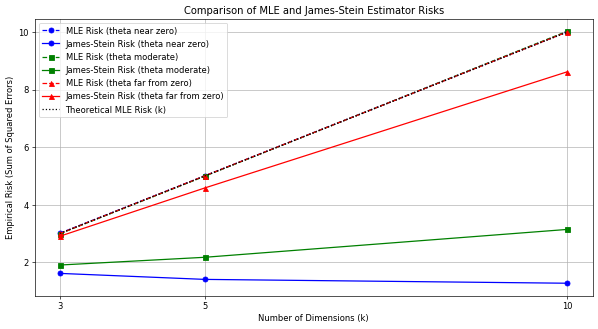

In [13]:
plt.figure(figsize=(12, 6), dpi=60)

scenario_colors = {
    "theta_near_zero": 'blue',
    "theta_moderate": 'green',
    "theta_far_from_zero": 'red'
}
scenario_markers = {
    "theta_near_zero": 'o',
    "theta_moderate": 's',
    "theta_far_from_zero": '^'
}

for scenario_name, scenario_data in results.items():
    k_values_plot = []
    mle_risks_plot = []
    js_risks_plot = []

    for k, (mle_risk, js_risk) in scenario_data.items():
        k_values_plot.append(k)
        mle_risks_plot.append(mle_risk)
        js_risks_plot.append(js_risk)

    # Plot MLE risks (should be close to k)
    plt.plot(k_values_plot, mle_risks_plot,
             label=f'MLE Risk ({scenario_name.replace("_", " ")})',
             color=scenario_colors[scenario_name], linestyle='--',
             marker=scenario_markers[scenario_name])

    # Plot James-Stein risks
    plt.plot(k_values_plot, js_risks_plot,
             label=f'James-Stein Risk ({scenario_name.replace("_", " ")})',
             color=scenario_colors[scenario_name], linestyle='-',
             marker=scenario_markers[scenario_name])

# Add theoretical MLE risk line
plt.plot(k_values, k_values, 'k:', label='Theoretical MLE Risk (k)')
plt.title('Comparison of MLE and James-Stein Estimator Risks')
plt.xlabel('Number of Dimensions (k)')
plt.ylabel('Empirical Risk (Sum of Squared Errors)')
plt.xticks(k_values) ; plt.grid(True) ; plt.legend() ; plt.show()

**Stein's Paradox and James-Stein Estimator**

We delved into Stein's paradox, explaining why the natural estimator $\hat{\theta}(X) = X$$\hat{\theta}(X) = X$ becomes inadmissible for $k \ge 3$$k \ge 3$ normal means, and introduced the James-Stein estimator as an improved alternative.

In [17]:
from tqdm import tqdm_notebook as tqdm

def plot_range(k, B=100000):
    error_mle, error_js = np.empty(B), np.empty(B)
    for i in tqdm(range(B)):
        theta = np.ones(k)
        X = simulate_data(theta, k)
        theta_hat_mle = mle_estimator(X)
        theta_hat_js = james_stein_estimator(X, k)
        error_mle[i] = squared_error_loss(theta, theta_hat_mle)
        error_js[i] = squared_error_loss(theta, theta_hat_js)
    plt.figure(figsize=(10, 6), dpi=60)
    plt.hist(error_mle, density=True, bins=100, alpha=0.5, label='MLE', histtype = 'step', color='blue')
    plt.hist(error_js, density=True, bins=100, alpha=0.5, label='James-Stein',
    histtype = 'step', color='red')
    plt.legend(loc='upper right') ; plt.show()

In [ ]:
plot_range(5)
plot_range(10)
plot_range(100)
plot_range(1000)

**Simulation of MLE vs. James-Stein Estimator**

We conducted simulation comparing the risk of the MLE and the James-Stein estimator across various dimensions (k) and true parameter vectors (theta). The results visually and numerically demonstrated that the James-Stein estimator consistently achieves lower risk than the MLE, especially when the true parameters are close to the shrinkage target.